# Linear regression to inspect dubious results of running economy paper: https://pmc.ncbi.nlm.nih.gov/articles/PMC5384070/
https://github.com/joshspeagle/dynesty/blob/master/demos/Examples%20--%20Linear%20Regression.ipynb

In [13]:



import numpy as np
import pylab as plt
import tensorflow_probability.substrates.jax as tfp
from jax import random
import jax.numpy as jnp

from jaxns.model import Model
from jaxns import results
from jaxns.core import NestedSampler
from jaxctx.priors.prior import Prior

tfpd = tfp.distributions

/tmp/ipykernel_909076/3181772269.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


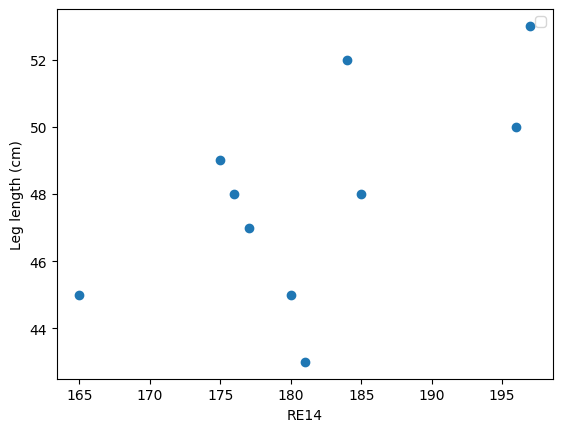

In [14]:

data = np.array(
    [[165, 45], [175, 49], [176, 48], [177, 47], [180, 45], [181, 43], [185, 48], [184, 52], [196, 50], [197, 53]],
    np.float64)
x_obs = data[:, 0]
y_obs = data[:, 1]

plt.scatter(x_obs, y_obs)
plt.xlabel('RE14')
plt.ylabel('Leg length (cm)')
plt.legend()
plt.show()

In [15]:



def log_likelihood(m, b, x_uncert, y_uncert):
    # Variance of each point along the y-direction after integrating out x*
    var = y_uncert ** 2 + (m ** 2) * x_uncert ** 2  # σ_y^2 + m² σ_x²
    res = y_obs - (m * x_obs + b)  # vertical residuals

    # Point-wise log-likelihood and its sum
    ll = -0.5 * (jnp.log(2 * np.pi * var) + res ** 2 / var)
    return ll.sum()


def prior_model_linear():
    m_upper = (np.max(y_obs) - np.min(y_obs)) / (np.max(y_obs) - np.min(y_obs))
    m_lower = -m_upper
    b_lower = np.min(y_obs) - m_upper * np.max(y_obs)
    b_upper = np.max(y_obs) - m_lower * np.min(y_obs)
    m = Prior(tfpd.Uniform(low=m_lower, high=m_upper), name='m').realise()
    b = Prior(tfpd.Uniform(low=b_lower, high=b_upper), name='b').realise()
    y_uncert = Prior(tfpd.Uniform(low=0.1, high=5.0), name='y_uncert').realise()
    x_uncert = Prior(tfpd.Uniform(low=0.1, high=50.0), name='x_uncert').realise()
    var = y_uncert ** 2 + m ** 2 * x_uncert ** 2
    res = y_obs - (m * x_obs + b)  # vertical residuals

    # Point-wise log-likelihood and its sum
    ll = -0.5 * (jnp.log(2 * np.pi * var) + res ** 2 / var)
    return ll.sum()

model_linear = Model(prior_model=prior_model_linear)

def prior_model_constant():
    m_upper = (np.max(y_obs) - np.min(y_obs)) / (np.max(y_obs) - np.min(y_obs))
    m_lower = -m_upper
    b_lower = np.min(y_obs) - m_upper * np.max(y_obs)
    b_upper = np.max(y_obs) - m_lower * np.min(y_obs)
    b = Prior(tfpd.Uniform(low=b_lower, high=b_upper), name='b').realise()
    y_uncert = Prior(tfpd.Uniform(low=0.1, high=5.0), name='y_uncert').realise()
    mean = b
    return tfpd.Normal(loc=mean, scale=y_uncert).log_prob(y_obs).sum()


model_constant = Model(prior_model=prior_model_constant)



In [16]:


# Create the nested sampler class. In this case without any tuning.
ns = NestedSampler(model=model_linear, difficult_model=True)

termination_reason, state = ns(random.PRNGKey(42))
results_linear = ns.to_results(termination_reason=termination_reason, state=state)
log_Z_linear = results_linear.log_Z_mean

ns = NestedSampler(model=model_constant, difficult_model=True)

termination_reason, state = ns(random.PRNGKey(42))
results_constant = ns.to_results(termination_reason=termination_reason, state=state)
log_Z_constant = results_constant.log_Z_mean

constant_favour = np.exp(log_Z_constant - log_Z_linear)
print(f"Constant model is {constant_favour:.2f} times more likely than linear model.")


Constant model is 1.71 times more likely than linear model.


In [17]:
# We can use the summary utility to display results
ns.summary(results_linear)
ns.summary(results_constant)

--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 1664993
samples: 5600
phantom samples: 0
likelihood evals / sample: 297.3
phantom fraction (%): 0.0%
--------
logZ=-30.42 +- 0.14
max(logL)=-22.72
H=-5.77
ESS=757
--------
b: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
b: 21.0 +- 17.0 | -0.0 / 20.0 / 43.0 | 11.0 | 11.0
--------
m: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
m: 0.148 +- 0.095 | 0.03 / 0.153 / 0.266 | 0.204 | 0.204
--------
x_uncert: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
x_uncert: 15.0 +- 12.0 | 3.0 / 11.0 / 36.0 | 8.0 | 8.0
--------
y_uncert: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
y_uncert: 2.3 +- 1.0 | 0.9 / 2.4 / 3.7 | 1.8 | 1.8
--------
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 379728
samples: 2300
phantom samples: 0
likelihood evals / sample: 165.1
phantom fraction (%): 0.0%
------

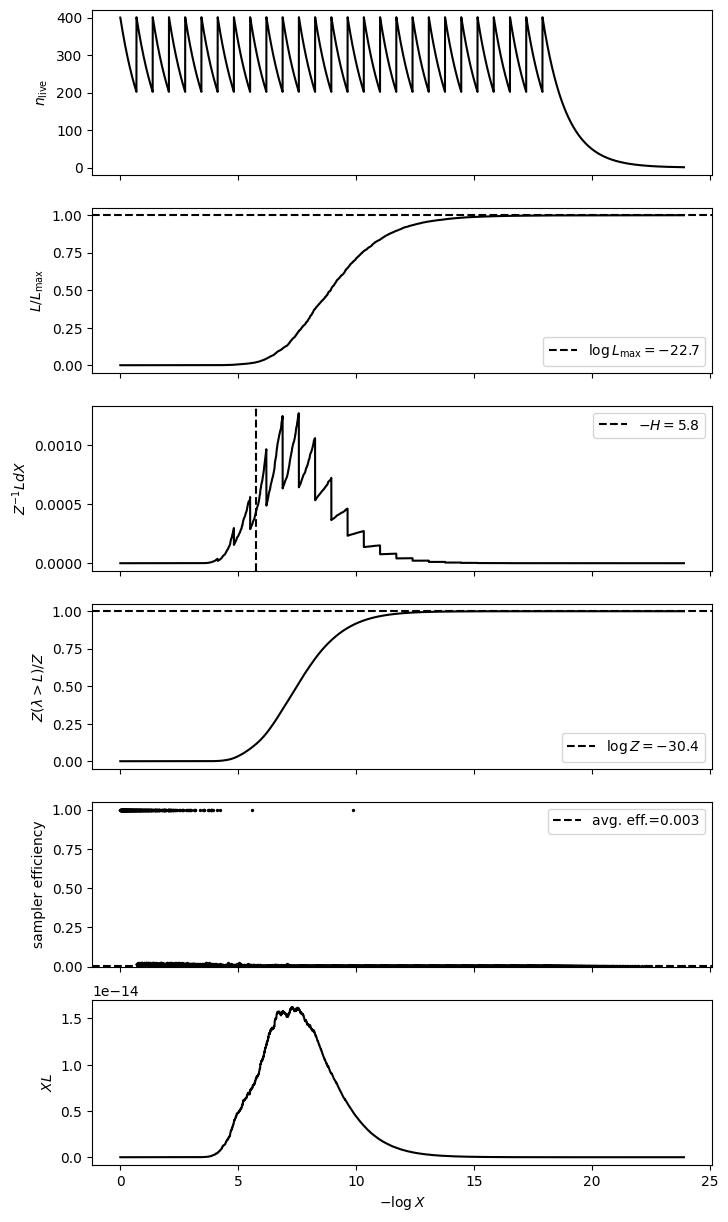

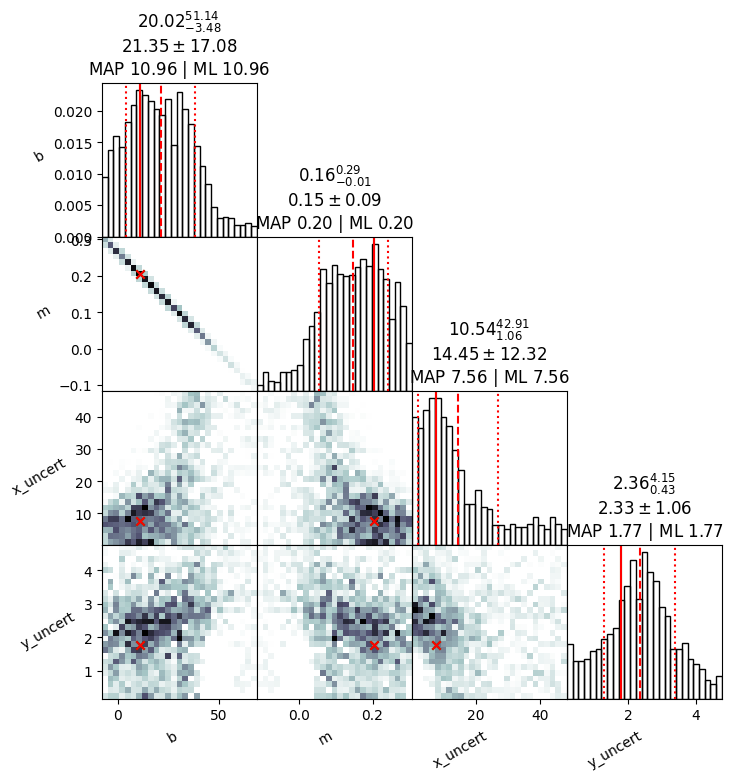

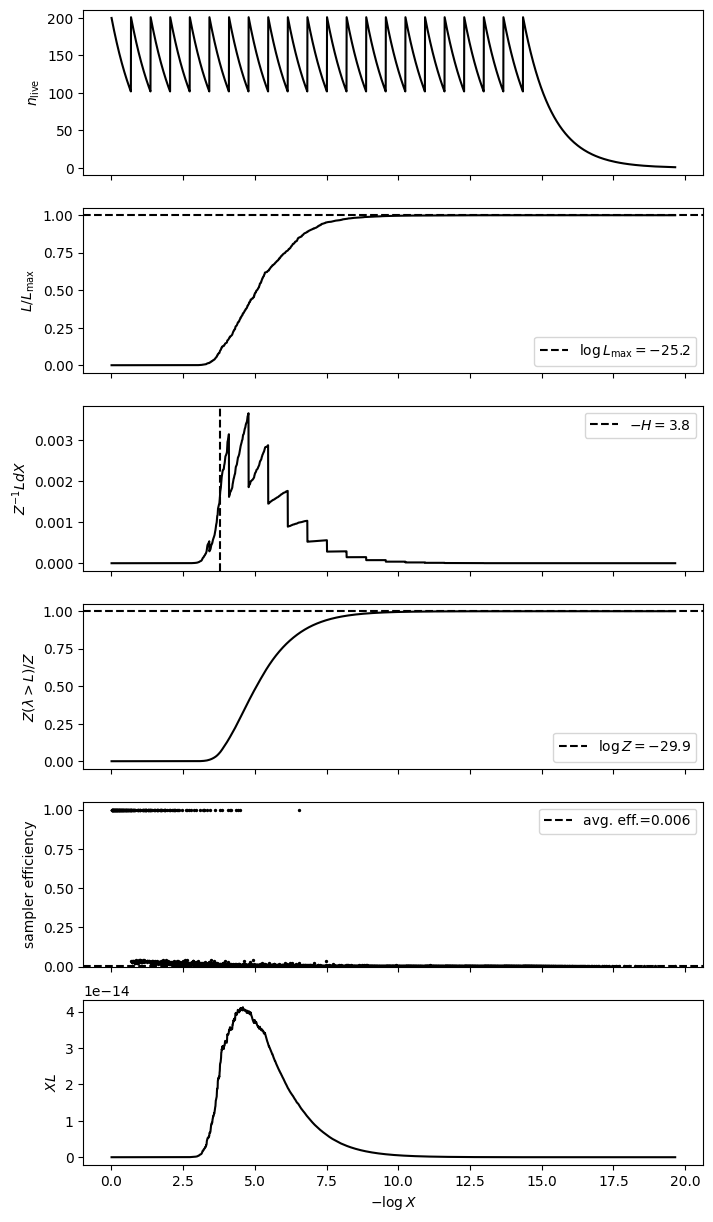

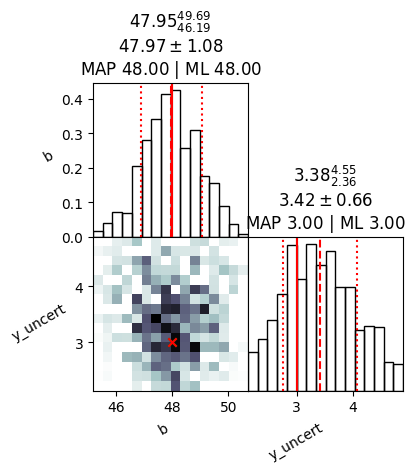

In [18]:
# We plot useful diagnostics and a distribution cornerplot
results.plot_diagnostics(results_linear)
results.plot_cornerplot(results_linear)
results.plot_diagnostics(results_constant)
results.plot_cornerplot(results_constant)